# Leakage field through a 50 µm × 50 µm opening in grounded Al

## Physical configuration

- The top Al plane is grounded: $V_{\mathrm{Al}}=0$ V.
- A square $50\times50~\mathrm{µm}^2$ opening exposes the top silicon surface.
- The exposed Si surface in the opening is held at $V_{\mathrm{Si}}=10$ V.
- The observation point is centered over the opening, 75 µm above the Al top surface.
- The Al thickness is 500 nm.

The air-side field is determined by the potential pattern on the top surface. Consequently, if the exposed Si surface is clamped at 10 V, the 675 µm substrate thickness and silicon permittivity do not enter the ideal air-region solution. They matter when calculating how the Si surface reaches 10 V, but not after that surface potential is prescribed.

This notebook gives both an **exact 3D analytical solution for the square opening** and an explicit **2D P1 finite-element solution** for its center cross-section. The 2D model represents an infinitely long 50 µm slot and therefore overestimates the leakage from the finite square.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "mathtext.fontset": "dejavusans",
})

COLORS = {"blue": "#275D8C", "orange": "#D17A22", "red": "#B33A3A", "gray": "#5B6573", "green": "#2A8C6A"}

In [2]:
# SI units
V_si = 10.0                  # exposed Si potential in opening, V
V_al = 0.0                   # grounded Al, V
opening_x = 50e-6            # opening size along x, m
opening_y = 50e-6            # opening size along y, m
a = opening_x / 2            # half-width along x, m
b = opening_y / 2            # half-width along y, m
z_obs = 75e-6                # height above Al top surface, m
t_al = 500e-9                # Al thickness / approximate recess depth, m
d_si = 675e-6                # Si thickness, m (not needed by prescribed-surface model)
eps_r_si = 11.7              # retained for documentation

### Voltage scaling

Laplace's equation and all Dirichlet boundary conditions are linear. If $V_{\mathrm{Si}}$ is multiplied by a factor $\alpha$, then

$$V(\mathbf r;\alpha V_{\mathrm{Si}})=\alpha V(\mathbf r;V_{\mathrm{Si}}),\qquad \mathbf E(\mathbf r;\alpha V_{\mathrm{Si}})=\alpha\mathbf E(\mathbf r;V_{\mathrm{Si}}).$$

Therefore changing the bias from 100 V to 10 V divides every potential and electric-field value by exactly ten, provided the material response remains linear and the prescribed Si surface voltage does not change shape.

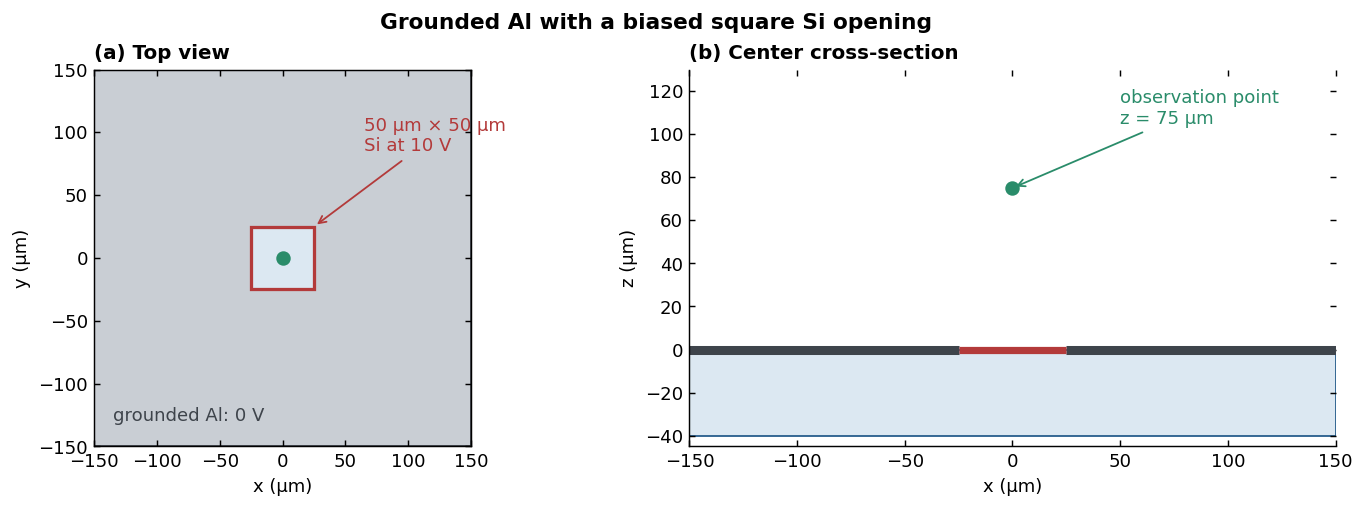

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8), constrained_layout=True)

# Top view
axes[0].add_patch(Rectangle((-150, -150), 300, 300, facecolor="#C9CED4", edgecolor="#3E444B"))
axes[0].add_patch(Rectangle((-25, -25), 50, 50, facecolor="#DCE8F2", edgecolor=COLORS["red"], lw=1.8))
axes[0].plot(0, 0, "o", ms=7, color=COLORS["green"])
axes[0].annotate("50 µm × 50 µm\nSi at 10 V", xy=(25, 25), xytext=(65, 85), color=COLORS["red"],
                 arrowprops=dict(arrowstyle="->", color=COLORS["red"]))
axes[0].text(-135, -130, "grounded Al: 0 V", color="#3E444B")
axes[0].set(xlim=(-150, 150), ylim=(-150, 150), aspect="equal", xlabel="x (µm)", ylabel="y (µm)")
axes[0].set_title("(a) Top view", loc="left", fontweight="bold")

# Center cross-section
axes[1].add_patch(Rectangle((-150, -40), 300, 40, facecolor="#DCE8F2", edgecolor=COLORS["blue"], lw=1.0))
axes[1].plot([-150, -25], [0, 0], color="#3E444B", lw=5, solid_capstyle="butt")
axes[1].plot([25, 150], [0, 0], color="#3E444B", lw=5, solid_capstyle="butt")
axes[1].plot([-25, 25], [0, 0], color=COLORS["red"], lw=4, solid_capstyle="butt")
axes[1].plot(0, 75, "o", ms=7, color=COLORS["green"])
axes[1].annotate("observation point\nz = 75 µm", xy=(0, 75), xytext=(50, 105), color=COLORS["green"],
                 arrowprops=dict(arrowstyle="->", color=COLORS["green"]))
axes[1].set(xlim=(-150, 150), ylim=(-45, 130), xlabel="x (µm)", ylabel="z (µm)")
axes[1].set_title("(b) Center cross-section", loc="left", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Grounded Al with a biased square Si opening", fontweight="bold")
plt.show()

## 1. Exact 3D solution for the square opening

For the upper half-space $z>0$, the boundary is $V=10$ V on the rectangular opening and $V=0$ on the surrounding grounded plane. The Poisson integral gives the potential as the solid angle $\Omega$ subtended by the opening:

$$V(x,y,z)=\frac{V_{\mathrm{Si}}}{2\pi}\,\Omega(x,y,z).$$

For a rectangle $-a<x'<a$, $-b<y'<b$, define

$$F(X,Y,z)=\tan^{-1}\!\left(\frac{XY}{z\sqrt{X^2+Y^2+z^2}}\right),$$

$$\Omega=F(a-x,b-y,z)-F(-a-x,b-y,z)-F(a-x,-b-y,z)+F(-a-x,-b-y,z).$$

On the center axis,

$$V(0,0,z)=\frac{2V_{\mathrm{Si}}}{\pi}\tan^{-1}\!\left(\frac{ab}{z\sqrt{z^2+a^2+b^2}}\right).$$

Let $c=a^2+b^2$ and $q=ab/[z\sqrt{z^2+c}]$. The upward field is

$$\boxed{E_z(0,0,z)=\frac{2V_{\mathrm{Si}}}{\pi}\frac{q}{1+q^2}\frac{2z^2+c}{z(z^2+c)}}.$$

This is the primary result for the actual $50\times50~\mathrm{µm}^2$ opening.

In [4]:
def rectangle_solid_angle(x, y, z, half_x=a, half_y=b):
    """Solid angle of a centered rectangle viewed from (x, y, z), z > 0."""
    x, y, z = np.broadcast_arrays(np.asarray(x, float), np.asarray(y, float), np.asarray(z, float))

    def corner(X, Y):
        R = np.sqrt(X**2 + Y**2 + z**2)
        return np.arctan((X * Y) / (z * R))

    return (corner(half_x - x, half_y - y)
            - corner(-half_x - x, half_y - y)
            - corner(half_x - x, -half_y - y)
            + corner(-half_x - x, -half_y - y))


def rectangle_potential(x, y, z, voltage=V_si):
    return voltage * rectangle_solid_angle(x, y, z) / (2 * np.pi)


def rectangle_center_field(z, half_x=a, half_y=b, voltage=V_si):
    """Exact positive Ez on the symmetry axis of the rectangular opening."""
    z = np.asarray(z, float)
    c = half_x**2 + half_y**2
    q = half_x * half_y / (z * np.sqrt(z**2 + c))
    return (2 * voltage / np.pi) * (q / (1 + q**2)) * (2*z**2 + c) / (z * (z**2 + c))


def slot_potential_2d(x, z, half_width=a, voltage=V_si):
    """Exact 2D potential for a biased slot in an otherwise grounded line."""
    return voltage / np.pi * (np.arctan2(half_width - x, z) + np.arctan2(half_width + x, z))


def slot_field_2d(x, z, half_width=a, voltage=V_si):
    left = z**2 + (half_width - x)**2
    right = z**2 + (half_width + x)**2
    ex = voltage * z / np.pi * (1/right - 1/left)
    ez = voltage / np.pi * ((half_width - x)/left + (half_width + x)/right)
    return ex, ez


V_3d = float(rectangle_potential(0.0, 0.0, z_obs))
E_3d = float(rectangle_center_field(z_obs))
E_3d_recess = float(rectangle_center_field(z_obs + t_al))
Ex_2d, Ez_2d = slot_field_2d(0.0, z_obs)
E_2d = float(np.hypot(Ex_2d, Ez_2d))

print("ANALYTICAL RESULTS AT THE CENTER OF THE 50 µm × 50 µm OPENING")
print(f"  Exact 3D square-aperture potential, z=75 µm : {V_3d:9.5f} V")
print(f"  Exact 3D square-aperture field, z=75 µm     : {E_3d/1e3:9.4f} V/mm")
print(f"  Approx. 500 nm recess correction, z=75.5 µm : {E_3d_recess/1e3:9.4f} V/mm")
print(f"  Exact 2D infinite-slot field, z=75 µm       : {E_2d/1e3:9.4f} V/mm")
print(f"  2D slot / 3D square ratio                   : {E_2d/E_3d:9.3f}")

ANALYTICAL RESULTS AT THE CENTER OF THE 50 µm × 50 µm OPENING
  Exact 3D square-aperture potential, z=75 µm :   0.63769 V
  Exact 3D square-aperture field, z=75 µm     :   15.3558 V/mm
  Approx. 500 nm recess correction, z=75.5 µm :   15.0908 V/mm
  Exact 2D infinite-slot field, z=75 µm       :   25.4648 V/mm
  2D slot / 3D square ratio                   :     1.658


### Voltage sweep: 1–100 V

Laplace's equation and these voltage boundary conditions are linear. Therefore the potential and electric field scale exactly with the applied Si bias: doubling the bias doubles the field everywhere. The sweep below reports the field in **V/mm**, a convenient unit for trapped-ion work.

VOLTAGE SWEEP AT THE CENTER, 75 µm ABOVE THE OPENING
  Exact linear relation: E_z = 1.535585 × bias  V/mm

 bias       exact 3D field    with 500 nm recess    potential at point
    1.0 V          1.5356 V/mm           1.5091 V/mm           0.06377 V
    5.0 V          7.6779 V/mm           7.5454 V/mm           0.31884 V
   10.0 V         15.3558 V/mm          15.0908 V/mm           0.63769 V
   25.0 V         38.3896 V/mm          37.7270 V/mm           1.59421 V
   50.0 V         76.7792 V/mm          75.4540 V/mm           3.18843 V
  100.0 V        153.5585 V/mm         150.9080 V/mm           6.37686 V


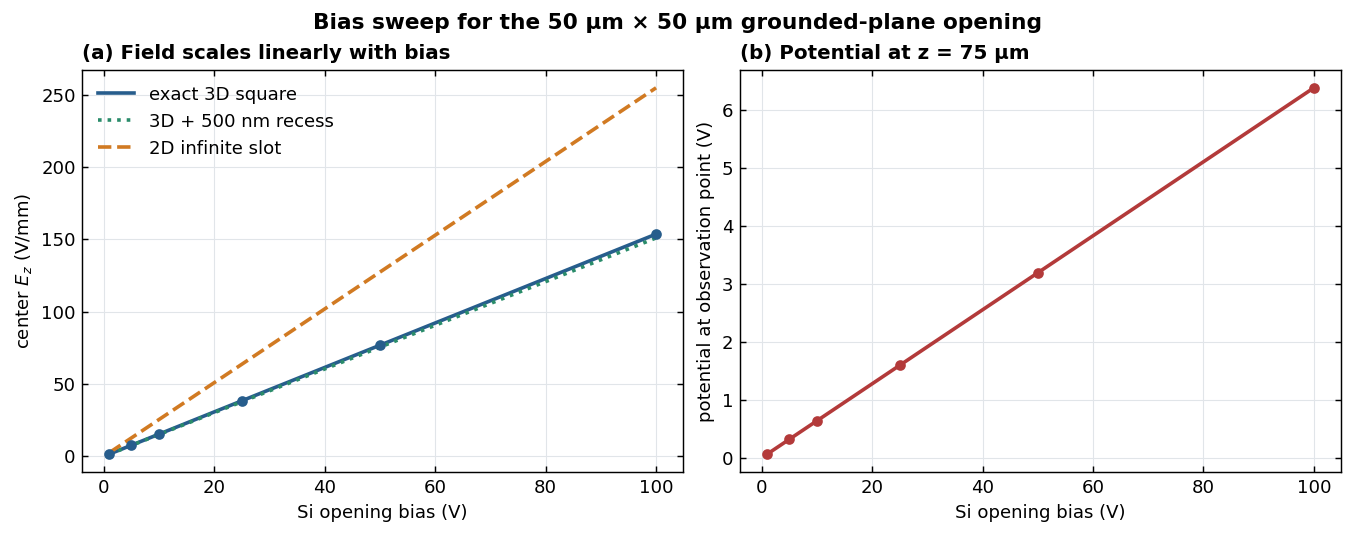

In [5]:
bias_sweep = np.linspace(1.0, 100.0, 400)
selected_biases = np.array([1.0, 5.0, 10.0, 25.0, 50.0, 100.0])

# Direct evaluation makes the linearity explicit and does not depend on V_si.
E3_sweep = rectangle_center_field(z_obs, voltage=bias_sweep) / 1e3
E3_recess_sweep = rectangle_center_field(z_obs + t_al, voltage=bias_sweep) / 1e3
E2_sweep = np.array([slot_field_2d(0.0, z_obs, voltage=v)[1] for v in bias_sweep]) / 1e3
Vpoint_sweep = rectangle_potential(0.0, 0.0, z_obs, voltage=bias_sweep)

E3_selected = rectangle_center_field(z_obs, voltage=selected_biases) / 1e3
E3_recess_selected = rectangle_center_field(z_obs + t_al, voltage=selected_biases) / 1e3
Vpoint_selected = rectangle_potential(0.0, 0.0, z_obs, voltage=selected_biases)
field_per_volt = float(rectangle_center_field(z_obs, voltage=1.0) / 1e3)

print("VOLTAGE SWEEP AT THE CENTER, 75 µm ABOVE THE OPENING")
print(f"  Exact linear relation: E_z = {field_per_volt:.6f} × bias  V/mm")
print("\n bias       exact 3D field    with 500 nm recess    potential at point")
for vb, e3, e3r, vp in zip(selected_biases, E3_selected, E3_recess_selected, Vpoint_selected):
    print(f" {vb:6.1f} V      {e3:10.4f} V/mm       {e3r:10.4f} V/mm         {vp:9.5f} V")

fig, axes = plt.subplots(1, 2, figsize=(10.3, 4.0), constrained_layout=True)

axes[0].plot(bias_sweep, E3_sweep, color=COLORS["blue"], label="exact 3D square")
axes[0].plot(bias_sweep, E3_recess_sweep, color=COLORS["green"], ls=":", label="3D + 500 nm recess")
axes[0].plot(bias_sweep, E2_sweep, color=COLORS["orange"], ls="--", label="2D infinite slot")
axes[0].scatter(selected_biases, E3_selected, s=24, color=COLORS["blue"], zorder=3)
axes[0].set(xlabel="Si opening bias (V)", ylabel=r"center $E_z$ (V/mm)")
axes[0].set_title("(a) Field scales linearly with bias", loc="left", fontweight="bold")
axes[0].grid(True, color="#E1E5E9", lw=0.6)
axes[0].legend()

axes[1].plot(bias_sweep, Vpoint_sweep, color=COLORS["red"])
axes[1].scatter(selected_biases, Vpoint_selected, s=24, color=COLORS["red"], zorder=3)
axes[1].set(xlabel="Si opening bias (V)", ylabel="potential at observation point (V)")
axes[1].set_title("(b) Potential at z = 75 µm", loc="left", fontweight="bold")
axes[1].grid(True, color="#E1E5E9", lw=0.6)

fig.suptitle("Bias sweep for the 50 µm × 50 µm grounded-plane opening", fontweight="bold")
plt.show()

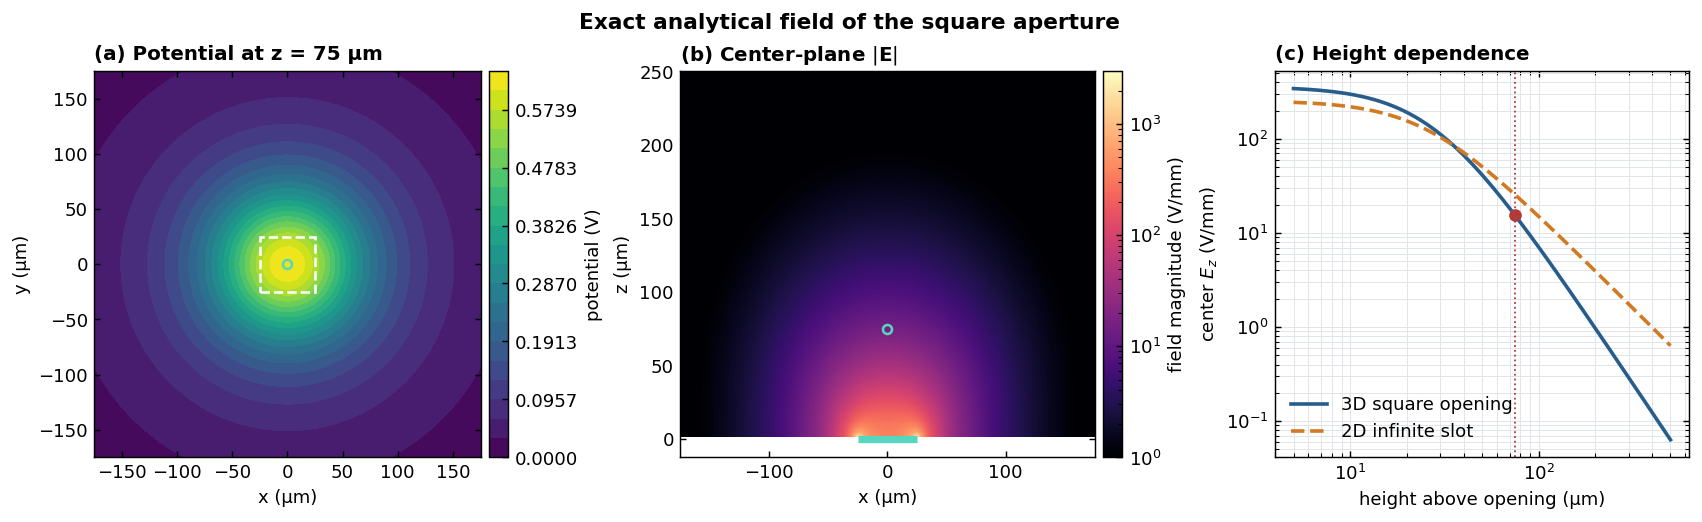

In [6]:
# Exact 3D analytical maps
xy = np.linspace(-175e-6, 175e-6, 351)
X, Y = np.meshgrid(xy, xy)
V_topview = rectangle_potential(X, Y, z_obs)

x_slice = np.linspace(-175e-6, 175e-6, 401)
z_slice = np.linspace(2e-6, 250e-6, 300)
XS, ZS = np.meshgrid(x_slice, z_slice)
V_slice = rectangle_potential(XS, 0.0, ZS)
dV_dz, dV_dx = np.gradient(V_slice, z_slice, x_slice, edge_order=2)
E_slice = np.hypot(dV_dx, dV_dz)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9), constrained_layout=True)

im0 = axes[0].contourf(X*1e6, Y*1e6, V_topview, levels=np.linspace(0, V_topview.max(), 21), cmap="viridis")
axes[0].add_patch(Rectangle((-25, -25), 50, 50, fill=False, edgecolor="white", lw=1.4, ls="--"))
axes[0].plot(0, 0, "o", ms=5, mfc="none", mec="#55D6BE", mew=1.4)
axes[0].set(aspect="equal", xlabel="x (µm)", ylabel="y (µm)")
axes[0].set_title("(a) Potential at z = 75 µm", loc="left", fontweight="bold")
cb0 = fig.colorbar(im0, ax=axes[0], pad=0.02)
cb0.set_label("potential (V)")

im1 = axes[1].pcolormesh(XS*1e6, ZS*1e6, E_slice/1e3, shading="auto", cmap="magma", norm=LogNorm(vmin=1, vmax=3e3))
axes[1].plot([-25, 25], [0, 0], color="#55D6BE", lw=4, solid_capstyle="butt")
axes[1].plot(0, 75, "o", ms=5, mfc="none", mec="#55D6BE", mew=1.4)
axes[1].set(xlabel="x (µm)", ylabel="z (µm)")
axes[1].set_title(r"(b) Center-plane $|\mathbf{E}|$", loc="left", fontweight="bold")
cb1 = fig.colorbar(im1, ax=axes[1], pad=0.02)
cb1.set_label("field magnitude (V/mm)")

z_line = np.geomspace(5e-6, 500e-6, 500)
e3_line = rectangle_center_field(z_line)
e2_line = np.array([slot_field_2d(0.0, zi)[1] for zi in z_line])
axes[2].loglog(z_line*1e6, e3_line/1e3, label="3D square opening", color=COLORS["blue"])
axes[2].loglog(z_line*1e6, e2_line/1e3, label="2D infinite slot", color=COLORS["orange"], ls="--")
axes[2].plot(75, E_3d/1e3, "o", color=COLORS["red"], ms=6)
axes[2].axvline(75, color=COLORS["red"], lw=1.0, ls=":")
axes[2].set(xlabel="height above opening (µm)", ylabel=r"center $E_z$ (V/mm)")
axes[2].set_title("(c) Height dependence", loc="left", fontweight="bold")
axes[2].grid(True, which="both", color="#E1E5E9", lw=0.55)
axes[2].legend()

fig.suptitle("Exact analytical field of the square aperture", fontweight="bold")
plt.show()

## 2. Independent numerical simulation in 3D

A spectral solver provides a full numerical 3D solution without reducing the square to a slot. Expand the prescribed surface voltage in lateral Fourier modes,

$$V(x,y,0)=\sum_{m,n}\widehat V_{mn}(0)e^{i(k_mx+k_ny)}.$$

Every mode solves Laplace's equation exactly in $z$:

$$\widehat V_{mn}(z)=\widehat V_{mn}(0)e^{-k_{mn}z},\qquad k_{mn}=\sqrt{k_m^2+k_n^2}.$$

For the rectangular opening, its Fourier coefficients are known analytically, so the aperture is not pixelated:

$$\widehat V_{mn}(0)=V_{\mathrm{Si}}\frac{2a}{L}\frac{2b}{L}\,\mathrm{sinc}\!\left(\frac{k_ma}{\pi}\right)\mathrm{sinc}\!\left(\frac{k_nb}{\pi}\right).$$

The calculation below uses a periodic lateral box and demonstrates convergence as the box is expanded. A 1024 × 1024 inverse FFT then produces the full 3D numerical field plane at $z=75$ µm.

In [7]:
def spectral_coefficients(box_size, n_grid):
    dx = box_size / n_grid
    k = 2*np.pi*np.fft.fftfreq(n_grid, d=dx)
    kx, ky = np.meshgrid(k, k, indexing="xy")
    kr = np.hypot(kx, ky)
    coeff = (V_si * (2*a/box_size) * (2*b/box_size)
             * np.sinc(kx*a/np.pi) * np.sinc(ky*b/np.pi))
    return kx, ky, kr, coeff


def spectral_center_value(box_size, n_grid, height=z_obs):
    _, _, kr, coeff = spectral_coefficients(box_size, n_grid)
    decay = np.exp(-kr*height)
    return float(np.sum(coeff*decay)), float(np.sum(kr*coeff*decay))


# Periodic-image / lateral-domain convergence
spectral_rows = []
for box_size in (0.5e-3, 1e-3, 2e-3, 4e-3):
    v_center, ez_center = spectral_center_value(box_size, 512)
    spectral_rows.append((box_size, v_center, ez_center))

# Full 3D numerical field plane at z = 75 µm
box_3d = 4e-3
n_3d = 1024
kx, ky, kr, coeff = spectral_coefficients(box_3d, n_3d)
decay = np.exp(-kr*z_obs)
vhat = n_3d**2 * coeff * decay
V_fft = np.fft.fftshift(np.fft.ifft2(vhat).real)
Ex_fft = np.fft.fftshift(np.fft.ifft2(-1j*kx*vhat).real)
Ey_fft = np.fft.fftshift(np.fft.ifft2(-1j*ky*vhat).real)
Ez_fft = np.fft.fftshift(np.fft.ifft2(kr*vhat).real)
E_fft = np.sqrt(Ex_fft**2 + Ey_fft**2 + Ez_fft**2)
xy_fft = (np.arange(n_3d) - n_3d//2) * box_3d/n_3d
center_index = n_3d//2
V_fft_center = float(V_fft[center_index, center_index])
E_fft_center = float(Ez_fft[center_index, center_index])

print("3D SPECTRAL LAPLACE SIMULATION — DOMAIN CONVERGENCE")
print(" periodic box       V center       Ez center       field error")
for box_size, v_center, ez_center in spectral_rows:
    print(f" {box_size*1e3:>7.1f} mm       {v_center:>9.6f} V    {ez_center/1e3:>9.5f} V/mm    {ez_center/E_3d-1:>+9.3%}")

print("\nFINAL 3D NUMERICAL RESULT (4 mm box, 1024 × 1024 modes)")
print(f"  Spectral potential at center       : {V_fft_center:9.6f} V")
print(f"  Spectral Ez at center              : {E_fft_center/1e3:9.5f} V/mm")
print(f"  Exact analytical Ez                : {E_3d/1e3:9.5f} V/mm")
print(f"  Spectral relative error            : {E_fft_center/E_3d-1:+9.4%}")

3D SPECTRAL LAPLACE SIMULATION — DOMAIN CONVERGENCE
 periodic box       V center       Ez center       field error
     0.5 mm        0.658894 V     15.08359 V/mm      -1.773%
     1.0 mm        0.640370 V     15.32039 V/mm      -0.231%
     2.0 mm        0.638022 V     15.35137 V/mm      -0.029%
     4.0 mm        0.637728 V     15.35529 V/mm      -0.004%

FINAL 3D NUMERICAL RESULT (4 mm box, 1024 × 1024 modes)
  Spectral potential at center       :  0.637728 V
  Spectral Ez at center              :  15.35529 V/mm
  Exact analytical Ez                :  15.35585 V/mm
  Spectral relative error            :  -0.0037%


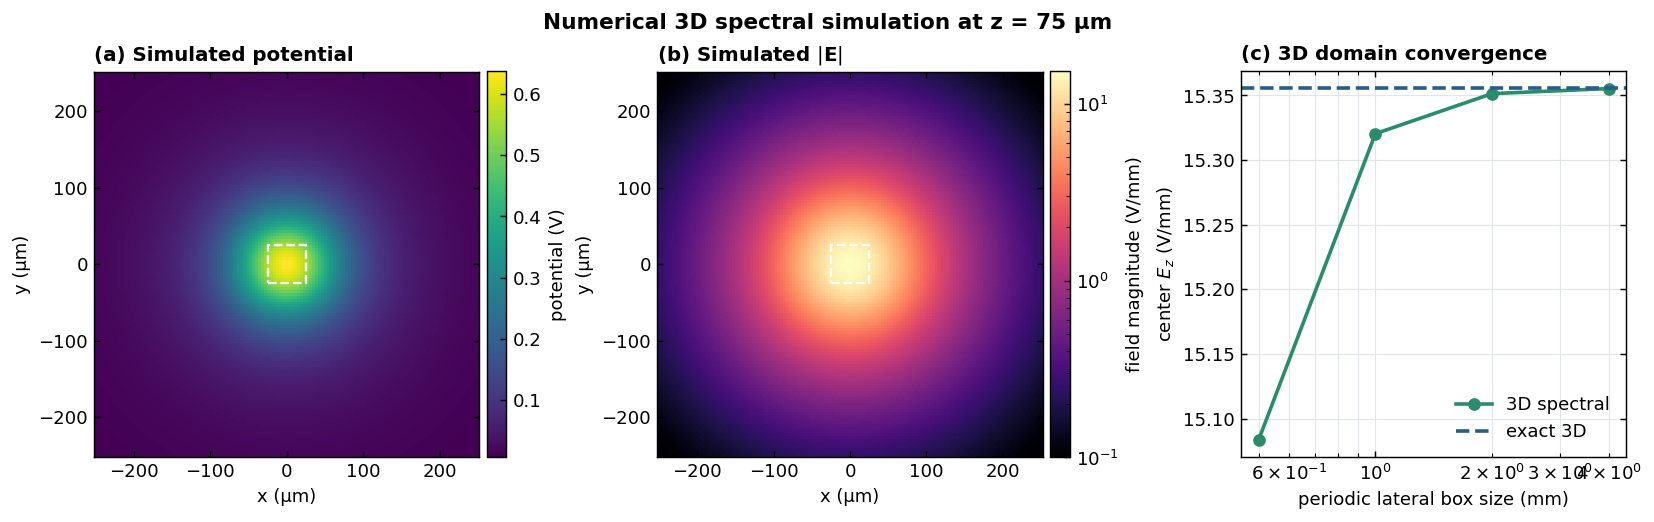

In [8]:
view = np.abs(xy_fft) <= 250e-6
xv = xy_fft[view]*1e6
V_view = V_fft[np.ix_(view, view)]
E_view = E_fft[np.ix_(view, view)]

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9), constrained_layout=True)

im0 = axes[0].pcolormesh(xv, xv, V_view, shading="auto", cmap="viridis")
axes[0].add_patch(Rectangle((-25, -25), 50, 50, fill=False, edgecolor="white", ls="--", lw=1.3))
axes[0].set(aspect="equal", xlabel="x (µm)", ylabel="y (µm)")
axes[0].set_title("(a) Simulated potential", loc="left", fontweight="bold")
cb0 = fig.colorbar(im0, ax=axes[0], pad=0.02)
cb0.set_label("potential (V)")

im1 = axes[1].pcolormesh(xv, xv, E_view/1e3, shading="auto", cmap="magma", norm=LogNorm(vmin=1e-1, vmax=E_view.max()/1e3))
axes[1].add_patch(Rectangle((-25, -25), 50, 50, fill=False, edgecolor="white", ls="--", lw=1.3))
axes[1].set(aspect="equal", xlabel="x (µm)", ylabel="y (µm)")
axes[1].set_title(r"(b) Simulated $|\mathbf{E}|$", loc="left", fontweight="bold")
cb1 = fig.colorbar(im1, ax=axes[1], pad=0.02)
cb1.set_label("field magnitude (V/mm)")

boxes = np.array([row[0] for row in spectral_rows])*1e3
fields_3d = np.array([row[2] for row in spectral_rows])/1e3
axes[2].semilogx(boxes, fields_3d, "o-", color=COLORS["green"], label="3D spectral")
axes[2].axhline(E_3d/1e3, color=COLORS["blue"], ls="--", label="exact 3D")
axes[2].set(xlabel="periodic lateral box size (mm)", ylabel=r"center $E_z$ (V/mm)")
axes[2].set_title("(c) 3D domain convergence", loc="left", fontweight="bold")
axes[2].grid(True, which="both", color="#E1E5E9", lw=0.6)
axes[2].legend()

fig.suptitle("Numerical 3D spectral simulation at z = 75 µm", fontweight="bold")
plt.show()

# Release the large FFT work arrays after plotting.
del kx, ky, kr, coeff, decay, vhat, Ex_fft, Ey_fft

## 3. Explicit 2D finite-element validation

A center cross-section through the square is a 50 µm-wide opening. In 2D that opening extends infinitely out of the page, so the FEM solves the intentionally conservative infinite-slot problem:

$$\nabla^2V=0\quad(z>0),$$

$$V(x,0)=\begin{cases}10\ \mathrm{V},&|x|<25\ \mathrm{µm},\\0,&|x|>25\ \mathrm{µm}.\end{cases}$$

For each linear triangular element,

$$K_{ij}^{(e)}=\frac{1}{4A_e}(b_i b_j+c_i c_j).$$

The sparse P1 system is assembled directly below. The exact 2D conformal-mapping solution is used as an independent validation target.

In [9]:
def make_slot_mesh(scale=1, x_extent=750e-6, z_extent=750e-6):
    """Conforming triangular mesh refined at both aperture edges and near z=0."""
    scale = int(scale)
    x_inside = np.linspace(-a, a, 40*scale + 1)
    t_side = np.linspace(0.0, 1.0, 40*scale + 1)[1:]
    x_right = a + (x_extent - a) * t_side**2
    x = np.r_[-x_right[::-1], x_inside, x_right]

    z_near = np.linspace(0.0, 300e-6, 60*scale + 1)
    t_far = np.linspace(0.0, 1.0, 30*scale + 1)[1:]
    z_far = 300e-6 + (z_extent - 300e-6) * t_far**2
    z = np.r_[z_near, z_far]

    X, Z = np.meshgrid(x, z)
    points = np.c_[X.ravel(), Z.ravel()]
    node = np.arange(len(points)).reshape(len(z), len(x))
    tri_1 = np.c_[node[:-1, :-1].ravel(), node[:-1, 1:].ravel(), node[1:, 1:].ravel()]
    tri_2 = np.c_[node[:-1, :-1].ravel(), node[1:, 1:].ravel(), node[1:, :-1].ravel()]
    triangles = np.vstack([tri_1, tri_2])
    return x, z, points, node, triangles


def solve_slot_fem(scale=1, x_extent=750e-6, z_extent=750e-6):
    x, z, points, node, triangles = make_slot_mesh(scale, x_extent, z_extent)
    p = points[triangles]
    px, pz = p[:, :, 0], p[:, :, 1]
    area = 0.5 * np.abs((px[:, 1]-px[:, 0])*(pz[:, 2]-pz[:, 0]) - (px[:, 2]-px[:, 0])*(pz[:, 1]-pz[:, 0]))
    b_e = np.c_[pz[:, 1]-pz[:, 2], pz[:, 2]-pz[:, 0], pz[:, 0]-pz[:, 1]]
    c_e = np.c_[px[:, 2]-px[:, 1], px[:, 0]-px[:, 2], px[:, 1]-px[:, 0]]
    ke = (b_e[:, :, None]*b_e[:, None, :] + c_e[:, :, None]*c_e[:, None, :]) / (4*area[:, None, None])
    rows = np.repeat(triangles, 3, axis=1).ravel()
    cols = np.tile(triangles, (1, 3)).ravel()
    K = coo_matrix((ke.ravel(), (rows, cols)), shape=(len(points), len(points))).tocsr()

    tol = 1e-12
    bottom = np.isclose(points[:, 1], 0.0, atol=tol)
    aperture = bottom & (np.abs(points[:, 0]) <= a + tol)
    outer = (bottom | np.isclose(np.abs(points[:, 0]), x_extent, atol=tol)
             | np.isclose(points[:, 1], z_extent, atol=tol))
    potential = np.zeros(len(points))
    potential[aperture] = V_si
    free = ~outer
    potential[free] = spsolve(K[free][:, free], -K[free][:, outer] @ potential[outer])

    return {"x": x, "z": z, "points": points, "node": node, "triangles": triangles,
            "potential": potential, "area": area, "b": b_e, "c": c_e, "scale": scale}


def slot_element_field(solution):
    u_e = solution["potential"][solution["triangles"]]
    ex = -np.sum(u_e * solution["b"], axis=1) / (2*solution["area"])
    ez = -np.sum(u_e * solution["c"], axis=1) / (2*solution["area"])
    return ex, ez


def slot_field_at_observation(solution):
    x, z = solution["x"], solution["z"]
    u = solution["potential"].reshape(len(z), len(x))
    ix = np.argmin(np.abs(x))
    iz = np.argmin(np.abs(z-z_obs))
    ex = -(u[iz, ix+1]-u[iz, ix-1])/(x[ix+1]-x[ix-1])
    ez = -(u[iz+1, ix]-u[iz-1, ix])/(z[iz+1]-z[iz-1])
    return float(u[iz, ix]), float(ex), float(ez), float(z[iz])

In [10]:
mesh_rows = []
solution_fem = None
for scale in (1, 2, 4):
    sol = solve_slot_fem(scale)
    v_pt, ex_pt, ez_pt, z_mesh = slot_field_at_observation(sol)
    mesh_rows.append((scale, len(sol["points"]), len(sol["triangles"]), v_pt, np.hypot(ex_pt, ez_pt)))
    if scale == 4:
        solution_fem = sol

V_fem, Ex_fem, Ez_fem, _ = slot_field_at_observation(solution_fem)
E_fem = np.hypot(Ex_fem, Ez_fem)

print("2D P1 FINITE-ELEMENT CONVERGENCE")
print(" scale       nodes    triangles     V(75 µm)       |E|(75 µm)")
for scale, nodes, tris, v_pt, e_pt in mesh_rows:
    print(f" {scale:>5d}  {nodes:>10,d}  {tris:>11,d}   {v_pt:>10.5f} V   {e_pt/1e3:>10.4f} V/mm")

print("\nVALIDATION AND PHYSICAL RESULT")
print(f"  Exact 2D infinite-slot field       : {E_2d/1e3:9.4f} V/mm")
print(f"  2D FEM infinite-slot field         : {E_fem/1e3:9.4f} V/mm")
print(f"  FEM relative error                 : {(E_fem/E_2d-1):9.3%}")
print(f"  Exact 3D square-opening field      : {E_3d/1e3:9.4f} V/mm  <-- use this")
print(f"  Approx. with 500 nm recess         : {E_3d_recess/1e3:9.4f} V/mm")

2D P1 FINITE-ELEMENT CONVERGENCE
 scale       nodes    triangles     V(75 µm)       |E|(75 µm)
     1      11,011       21,600      2.04695 V      25.9909 V/mm
     2      43,621       86,400      2.03430 V      25.7791 V/mm
     4     173,641      345,600      2.03113 V      25.7262 V/mm

VALIDATION AND PHYSICAL RESULT
  Exact 2D infinite-slot field       :   25.4648 V/mm
  2D FEM infinite-slot field         :   25.7262 V/mm
  FEM relative error                 :    1.027%
  Exact 3D square-opening field      :   15.3558 V/mm  <-- use this
  Approx. with 500 nm recess         :   15.0908 V/mm


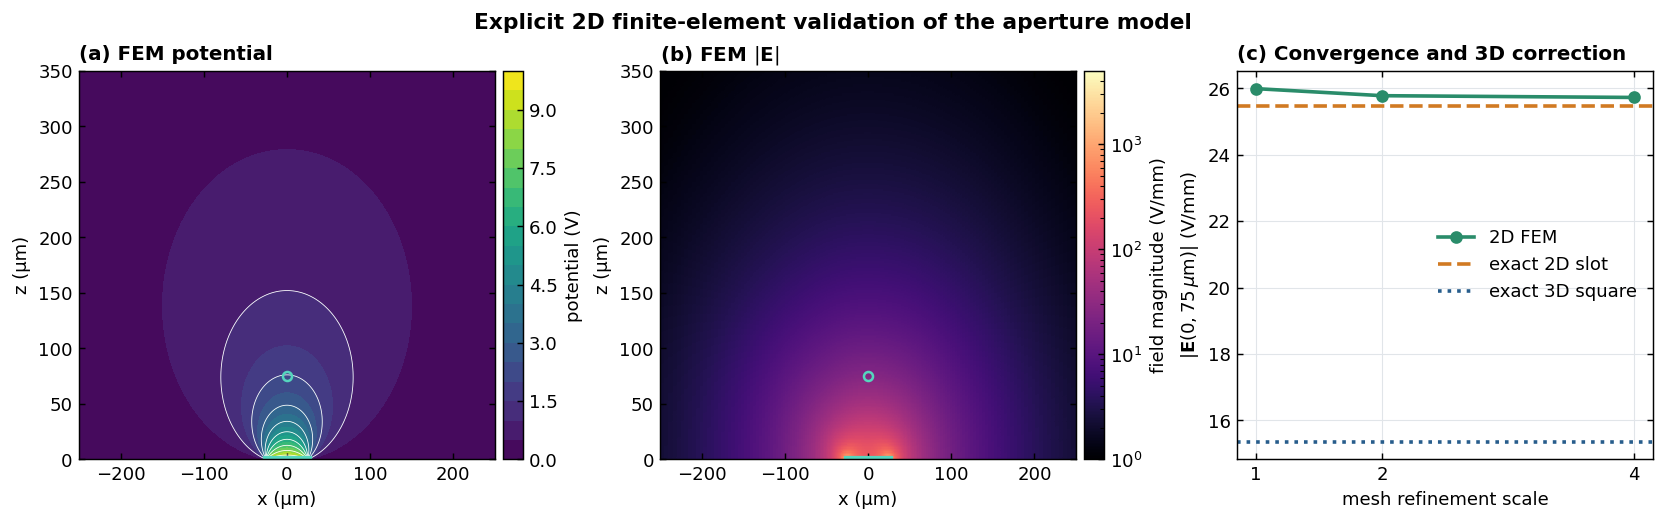

In [11]:
ex_e, ez_e = slot_element_field(solution_fem)
emag_e = np.hypot(ex_e, ez_e)
tri = mtri.Triangulation(solution_fem["points"][:, 0]*1e6,
                         solution_fem["points"][:, 1]*1e6,
                         solution_fem["triangles"])

fig, axes = plt.subplots(1, 3, figsize=(12.7, 3.9), constrained_layout=True)
pot = axes[0].tricontourf(tri, solution_fem["potential"], levels=np.linspace(0, V_si, 21), cmap="viridis")
axes[0].tricontour(tri, solution_fem["potential"], levels=np.linspace(0.1*V_si, 0.9*V_si, 9), colors="white", linewidths=0.45)
axes[0].plot([-25, 25], [0, 0], color="#55D6BE", lw=4)
axes[0].plot(0, 75, "o", ms=5, mfc="none", mec="#55D6BE", mew=1.4)
axes[0].set(xlim=(-250, 250), ylim=(0, 350), xlabel="x (µm)", ylabel="z (µm)")
axes[0].set_title("(a) FEM potential", loc="left", fontweight="bold")
cb0 = fig.colorbar(pot, ax=axes[0], pad=0.02)
cb0.set_label("potential (V)")

fld = axes[1].tripcolor(tri, facecolors=emag_e/1e3, shading="flat", cmap="magma", norm=LogNorm(vmin=1, vmax=5e3))
axes[1].plot([-25, 25], [0, 0], color="#55D6BE", lw=4)
axes[1].plot(0, 75, "o", ms=5, mfc="none", mec="#55D6BE", mew=1.4)
axes[1].set(xlim=(-250, 250), ylim=(0, 350), xlabel="x (µm)", ylabel="z (µm)")
axes[1].set_title(r"(b) FEM $|\mathbf{E}|$", loc="left", fontweight="bold")
cb1 = fig.colorbar(fld, ax=axes[1], pad=0.02)
cb1.set_label("field magnitude (V/mm)")

scales = np.array([row[0] for row in mesh_rows])
fields = np.array([row[-1] for row in mesh_rows])/1e3
axes[2].plot(scales, fields, "o-", color=COLORS["green"], label="2D FEM")
axes[2].axhline(E_2d/1e3, color=COLORS["orange"], ls="--", label="exact 2D slot")
axes[2].axhline(E_3d/1e3, color=COLORS["blue"], ls=":", label="exact 3D square")
axes[2].set(xlabel="mesh refinement scale", ylabel=r"$|\mathbf{E}(0,75\,\mu\mathrm{m})|$ (V/mm)", xticks=scales)
axes[2].set_title("(c) Convergence and 3D correction", loc="left", fontweight="bold")
axes[2].grid(True, color="#E1E5E9", lw=0.6)
axes[2].legend()

fig.suptitle("Explicit 2D finite-element validation of the aperture model", fontweight="bold")
plt.show()

## 4. Conclusion

For a centered observation point 75 µm above a $50\times50~\mathrm{µm}^2$ opening at 10 V, use the **exact 3D square-opening result**, independently confirmed by the converged 3D spectral simulation. Do not use the 2D slot value as the device prediction; the 2D opening is infinite out of the page and is deliberately conservative.

At 10 V the exact field is approximately **15.36 V/mm**; equivalently, the device response is **1.5356 V/mm per applied volt**. Thus the ideal result spans approximately 1.54–153.56 V/mm over the 1–100 V sweep.

The ideal solution assumes an abrupt exposed-Si potential patch flush with an infinite grounded plane. The 500 nm metal thickness changes the center field by only a few percent when approximated as an additional 0.5 µm distance. A more detailed model would include the aperture sidewall, any native oxide, rounded Al edges, and the actual spatial variation of the Si surface potential.

Near the sharp aperture boundary the ideal field is singular. The quoted center field at 75 µm is well away from that singularity.